# Task 1 - Date Feature Engineering

In [2]:
# Import required libraries
import pandas as pd

# Load dataset
df = pd.read_csv('q3_retail_promotions.csv')

# Convert transaction_date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract year, month, and day of week
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek  # Monday=0, Sunday=6

# Create is_month_end feature (1 if day >= 25, else 0)
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Display sample to verify new features
print(df.head())

  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  year  month  \
0           1            0                    5         224  2022      1   
1           1            1                    1         348  2022      1   
2           1            0                    6         249  2022      1   
3           1            0                    7         259  2022      1   
4           0            0                    3         277  2022      1   

   day_of_week  is_month_end  
0            5             0  
1            5             0  
2          

# Task 2 -  Temporal Train-Test Split

In [3]:
# Sort dataset by transaction_date
df = df.sort_values(by='transaction_date')

# Determine split index (80% train, 20% test)
split_index = int(len(df) * 0.8)

# Split without shuffling
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

# Separate features and target
X_train = train_df.drop('items_sold', axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop('items_sold', axis=1)
y_test = test_df['items_sold']

# Verify split sizes
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# Optional: check last train date and first test date
print("Last train date:", train_df['transaction_date'].max())
print("First test date:", test_df['transaction_date'].min())

Train size: (960, 12)
Test size: (240, 12)
Last train date: 2024-06-11 00:00:00
First test date: 2024-06-12 00:00:00


Why Random Split is Inappropriate (Markdown)


---


A random split is unsuitable for time-based data because it violates the fundamental assumption of temporal causality.

* **Data leakage risk:** Random splitting may place future records in the training set and past records in the test set.
* **Unrealistic evaluation:** The model gets access to information that would not be available in real-world forecasting.
* **Temporal dependencies ignored:** Sales data often contains trends, seasonality, and lag effects that must be learned sequentially.
* **Inflated performance metrics:** Results appear better than they actually are in production scenarios.


---


**Conclusion:**

Temporal splitting ensures that the model is trained only on past data and evaluated on future data, providing a realistic and reliable measure of performance.

# Task 3 - Preprocessing Pipeline

In [5]:
# Import required libraries
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define categorical and numerical columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']

# Drop 'transaction_date' from X_train and X_test as it's not a feature for the model
# and causes DTypePromotionError with StandardScaler.
# This column has already been used to create time-based features.
X_train = X_train.drop(columns=['transaction_date'])
X_test = X_test.drop(columns=['transaction_date'])

# All remaining columns (excluding target and dropped date) are treated as numerical
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

# Create transformers
categorical_transformer = OneHotEncoder(handle_unknown='ignore')
numerical_transformer = StandardScaler()

# Combine using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols),
        ('num', numerical_transformer, numerical_cols)
    ]
)

# Create full pipeline (preprocessing only for now)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Fit only on training data
pipeline.fit(X_train)

# Transform both train and test sets
X_train_processed = pipeline.transform(X_train)
X_test_processed = pipeline.transform(X_test)

# Check transformed shapes
print("Processed Train shape:", X_train_processed.shape)
print("Processed Test shape:", X_test_processed.shape)

Processed Train shape: (960, 19)
Processed Test shape: (240, 19)


# Task 4 - Model Training and Evaluation

Build Full Pipelines (Preprocessing + Model)

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Linear Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Fit models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size']),
                                                 ('num', StandardScaler(),
                                                  ['store_id', 'is_weekend',
                                                   'is_festival',
                                                   'competition_density',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end'])])),
                ('model', RandomForestRegressor(random_state=42))])

Evaluate Models (RMSE & MAE)

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

# Metrics
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Linear Regression -> RMSE:", rmse_lr, "MAE:", mae_lr)
print("Random Forest -> RMSE:", rmse_rf, "MAE:", mae_rf)

Linear Regression -> RMSE: 27.121451164890626 MAE: 21.052926674588395
Random Forest -> RMSE: 30.841610008504205 MAE: 24.240625


Parity Plots (Predicted vs Actual)

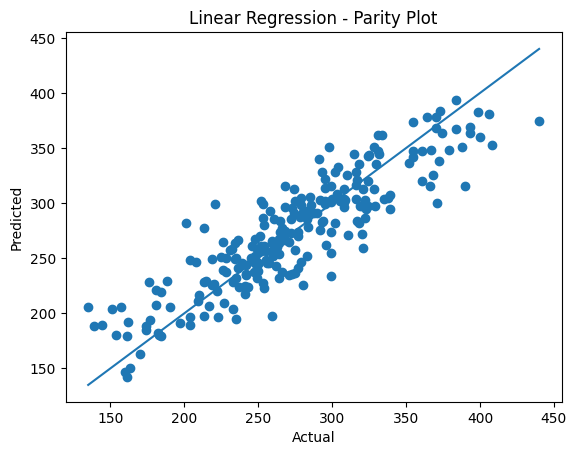

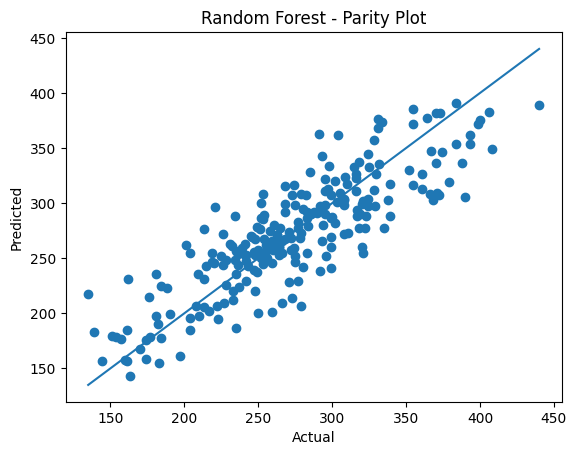

In [14]:
import matplotlib.pyplot as plt

# Linear Regression Plot
plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression - Parity Plot")
plt.show()

# Random Forest Plot
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest - Parity Plot")
plt.show()

Feature Importances (Random Forest)

In [15]:
# Get feature names after preprocessing
ohe = preprocessor.named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)

all_features = list(encoded_cat_features) + numerical_cols

# Extract feature importances
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create DataFrame
import pandas as pd
feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Top 5 features
top5 = feat_imp.head(5)

print("Top 5 Important Features:\n", top5)

Top 5 Important Features:
                 feature  importance
13          is_festival    0.173473
10     store_size_small    0.167683
7   location_type_urban    0.108378
17          day_of_week    0.086316
12           is_weekend    0.061208
